## Домашнее задание по теме «Свёрточные сети»

Постройте модель, используя архитектуру со свёрточными слоями, для классификации Fashion MNIST. Итоговое качество (accuracy) должно быть не ниже 89,5

Кол-во изображений для тренировки 60000, для теста 10000
Кол-во классов тренировки 10, для теста 10
torch.Size([1, 28, 28]) 1


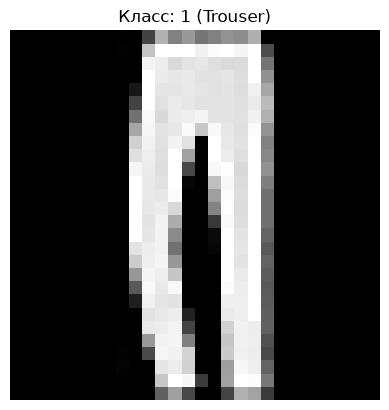

In [39]:
import torch
import torchvision
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

# Загрузка тренировочного датасета
train_dataset = torchvision.datasets.FashionMNIST(
    root='./2.data',  # Корневой каталог для хранения данных
    train=True,    # True для обучающей выборки, False для тестовой
    download=True, # Если True, данные будут скачаны из интернета
    transform=ToTensor()  # Преобразование данных в тензоры
)

# Загрузка тестового датасета
test_dataset = torchvision.datasets.FashionMNIST(
    root='./2.data',  # Корневой каталог тот же
    train=False,    # False для тестовой
    download=True,
    transform=ToTensor()
)

print(f'Кол-во изображений для тренировки {len(train_dataset)}, для теста {len(test_dataset)}')
print(f'Кол-во классов тренировки {len(train_dataset.classes)}, для теста {len(test_dataset.classes)}')

image, label = test_dataset[2] # 0 - ботинок, 1 - кафтан, 2 - варенки и т.д.

# image — это тензор [1, 28, 28], label это число, скаляр
print(image.shape, label)
image_np = image.squeeze().numpy() # убираем лишнюю размерность для imshow

plt.imshow(image_np, cmap='gray')
plt.title(f'Класс: {label} ({test_dataset.classes[label]})')
plt.axis('off')
plt.show()

In [40]:
BATCH_SIZE=256

train = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [45]:
import time

def evaluate_accuracy(data_iter, net):
    acc_sum, n = torch.Tensor([0]), 0
    for X, y in data_iter:
        acc_sum += (net(X).argmax(axis=1) == y).sum()
        n += y.shape[0]
    return acc_sum.item() / n

def train_model(net, train, test, optimizer, num_epochs):
    loss = torch.nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        train_l_sum, train_acc_sum, n, start = 0.0, 0.0, 0, time.time()
    
        for X, y in train:
            optimizer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            train_l_sum += l.item()
            train_acc_sum += (y_hat.argmax(axis=1) == y).sum().item()
            n += y.shape[0]
    
        test_acc = evaluate_accuracy(test, net)
        print(f'Эпоха {epoch + 1}, Трен. потери {train_l_sum / n:.4f}, Трен. точность {train_acc_sum / n:.3f}' \
              f', Тест точность {test_acc:.3f}, Время {time.time() - start:.1f} сек')

## Модель 1 

Модель Lenet адаптированная под размер картинки 28 на 28. Сделан апгрейд в виде BatchNorm. Удален AvgPool2d. За 11 эпох требуемая точность 0.895 была набрана.

In [59]:
from torchsummary import summary

model = torch.nn.Sequential( 
    #Flatten в начале не делаем (как в многослойных сетях) т.к. нужна 2D структура признаков
    torch.nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0),
    torch.nn.BatchNorm2d(6), # добавляем нормализацию
    # вычисление размера после свертки:
    # (W - K + 2P) / S + 1
    # Где W=28, K=5, P=0, S=1 
    # (28 - 5 + 0)/1 + 1 = 24
    # на выходе 6 карт 24 на 24
    torch.nn.Tanh(),
    torch.nn.AvgPool2d(2, stride=2),
    # Карта 24x24 превращается в 12x12
    torch.nn.Conv2d(6, 16, kernel_size=5),
    torch.nn.BatchNorm2d(16),
    # (12 - 5) / 1 + 1 = 8
    # 16 карт признаков размером 8x8
    torch.nn.Tanh(),
    #torch.nn.AvgPool2d(2, stride=2),
    # 8 на 8 в 4 на 4
    torch.nn.Conv2d(16, 240, kernel_size=8), # корректируем ядро, меняем 5 на 4 чтобы все срослось, меняем 120 на 240 (больше признаков)
    torch.nn.BatchNorm2d(240),
    # (8 - 8 + 0)/1 + 1 = 1 (16 каналов выдадут 1 число) Далее числа это выбор инженера Лекуна полученные экспериментально
    torch.nn.Flatten(),
    torch.nn.Linear(240, 120),
    torch.nn.BatchNorm1d(120),
    torch.nn.Tanh(),
    torch.nn.Linear(120, 84),
    torch.nn.BatchNorm1d(84),
    torch.nn.Tanh(),
    torch.nn.Linear(84, 10)
)
summary(model, input_size=(1, 28, 28), device='cpu')

num_epochs = 15
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_model(model, train, test, optimizer, num_epochs)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 24, 24]             156
       BatchNorm2d-2            [-1, 6, 24, 24]              12
              Tanh-3            [-1, 6, 24, 24]               0
         AvgPool2d-4            [-1, 6, 12, 12]               0
            Conv2d-5             [-1, 16, 8, 8]           2,416
       BatchNorm2d-6             [-1, 16, 8, 8]              32
              Tanh-7             [-1, 16, 8, 8]               0
            Conv2d-8            [-1, 240, 1, 1]         246,000
       BatchNorm2d-9            [-1, 240, 1, 1]             480
          Flatten-10                  [-1, 240]               0
           Linear-11                  [-1, 120]          28,920
      BatchNorm1d-12                  [-1, 120]             240
             Tanh-13                  [-1, 120]               0
           Linear-14                   

## Попытка улучшить модель

Меняем тангенс на relu, убираем грубое ядро 8 на 8 и переписываем чтобы было больше ядер. Считается дольше, но на 11-й эпохе точность 0.9

In [65]:
from torchsummary import summary

model = torch.nn.Sequential( 
    #Flatten в начале не делаем (как в многослойных сетях) т.к. нужна 2D структура признаков
    torch.nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0),
    torch.nn.BatchNorm2d(6), # добавляем нормализацию
    # вычисление размера после свертки:
    # (W - K + 2P) / S + 1
    # Где W=28, K=5, P=0, S=1 
    # (28 - 5 + 0)/1 + 1 = 24
    # на выходе 6 карт 24 на 24
    torch.nn.ReLU(),
    torch.nn.AvgPool2d(2, stride=2),
    # Карта 24x24 превращается в 12x12
    torch.nn.Conv2d(6, 16, kernel_size=5),
    torch.nn.BatchNorm2d(16),
    # (12 - 5) / 1 + 1 = 8
    # 16 карт признаков размером 8x8
    torch.nn.ReLU(),
    #torch.nn.AvgPool2d(2, stride=2),
    # 8 на 8 в 4 на 4
    torch.nn.Conv2d(16, 120, kernel_size=3, padding=1), # корректируем ядро, меняем 5 на 4 чтобы все срослось, меняем 120 на 240 (больше признаков)
    # (8 - 3 + 2) / 1 + 1 = 8
    torch.nn.BatchNorm2d(120),
    torch.nn.ReLU(),
    torch.nn.Conv2d(120, 240, kernel_size=3, padding=1),
    # (6 - 3 + 2) / 1 + 1 = 6
    torch.nn.BatchNorm2d(240),
    torch.nn.AdaptiveAvgPool2d(1),
    torch.nn.ReLU(),
    torch.nn.Flatten(),
    torch.nn.Linear(240, 120),
    torch.nn.BatchNorm1d(120),
    torch.nn.ReLU(),
    torch.nn.Linear(120, 84),
    torch.nn.BatchNorm1d(84),
    torch.nn.ReLU(),
    torch.nn.Linear(84, 10)
)
summary(model, input_size=(1, 28, 28), device='cpu')

num_epochs = 15
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_model(model, train, test, optimizer, num_epochs)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 24, 24]             156
       BatchNorm2d-2            [-1, 6, 24, 24]              12
              ReLU-3            [-1, 6, 24, 24]               0
         AvgPool2d-4            [-1, 6, 12, 12]               0
            Conv2d-5             [-1, 16, 8, 8]           2,416
       BatchNorm2d-6             [-1, 16, 8, 8]              32
              ReLU-7             [-1, 16, 8, 8]               0
            Conv2d-8            [-1, 120, 8, 8]          17,400
       BatchNorm2d-9            [-1, 120, 8, 8]             240
             ReLU-10            [-1, 120, 8, 8]               0
           Conv2d-11            [-1, 240, 8, 8]         259,440
      BatchNorm2d-12            [-1, 240, 8, 8]             480
AdaptiveAvgPool2d-13            [-1, 240, 1, 1]               0
             ReLU-14            [-1, 24